In [6]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

Loading datasets and calculating boundaries for 3 buckets...


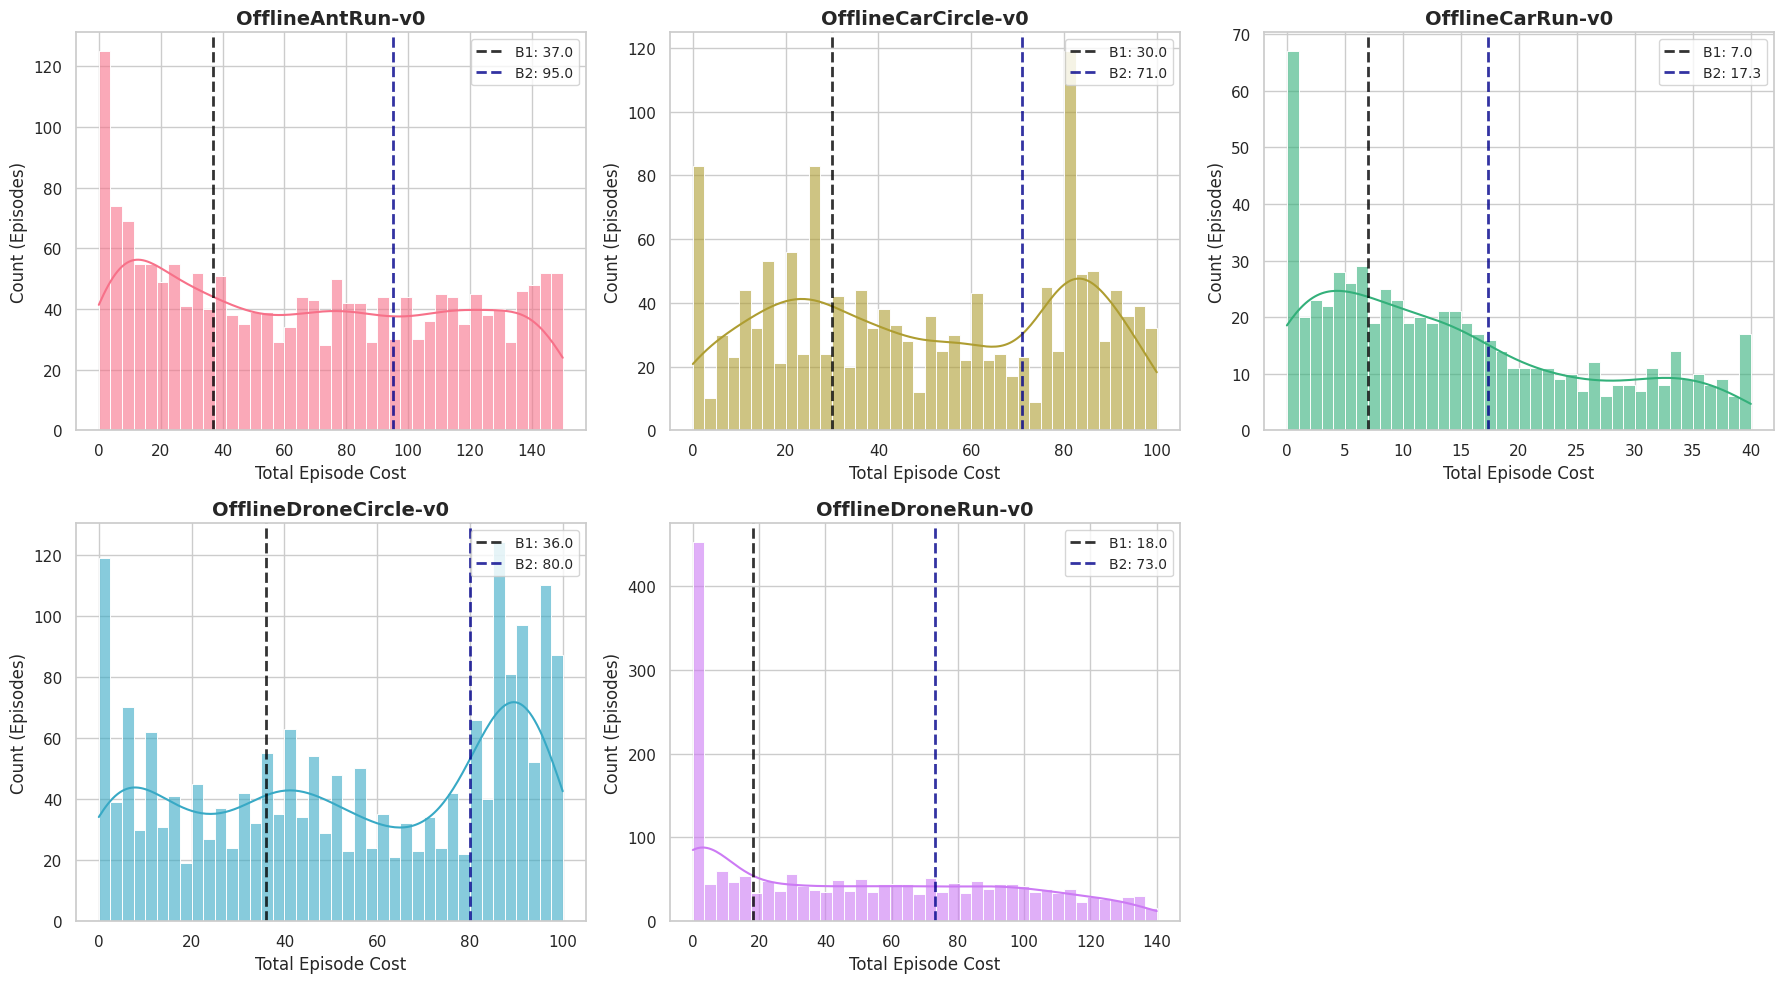

In [11]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Change this number to see how the splits shift!
num_buckets = 3 

dataset_dir = "/home/20234949/thesis/datasets"
env_files = {
    "OfflineAntRun-v0": "SafetyAntRun-v0-150-1816.hdf5",
    "OfflineCarCircle-v0": "SafetyCarCircle-v0-100-1450.hdf5",
    "OfflineCarRun-v0": "SafetyCarRun-v0-40-651.hdf5",
    "OfflineDroneCircle-v0": "SafetyDroneCircle-v0-100-1923.hdf5",
    "OfflineDroneRun-v0": "SafetyDroneRun-v0-140-1990.hdf5"
}

sns.set_theme(style="whitegrid")

# ==========================================
# 2. EXTRACT DATA
# ==========================================
env_episode_costs = {}
print(f"Loading datasets and calculating boundaries for {num_buckets} buckets...")

for env_name, filename in env_files.items():
    filepath = os.path.join(dataset_dir, filename)
    
    if not os.path.exists(filepath):
        print(f"⚠️ Warning: Could not find {filepath}")
        continue
        
    dataset = {}
    with h5py.File(filepath, 'r') as f:
        for k in f.keys():
            if isinstance(f[k], h5py.Dataset):
                dataset[k] = f[k][:]
            elif isinstance(f[k], h5py.Group) and k == 'infos':
                for info_k in f[k].keys():
                    dataset[info_k] = f[k][info_k][:]
    
    costs = dataset.get('costs', dataset.get('cost'))
    terminals = dataset.get('terminals', dataset.get('dones'))
    timeouts = dataset.get('timeouts', np.zeros_like(terminals, dtype=bool))
    
    episode_ends = np.where(np.logical_or(terminals, timeouts))[0]
    
    ep_costs = []
    start_idx = 0
    for end_idx in episode_ends:
        ep_costs.append(np.sum(costs[start_idx:end_idx + 1]))
        start_idx = end_idx + 1
        
    env_episode_costs[env_name] = np.array(ep_costs)

# ==========================================
# 3. PLOT DISTRIBUTIONS & BOUNDARIES
# ==========================================
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

# Base colors for the histograms
colors = sns.color_palette("husl", len(env_episode_costs))
# Colors for the boundary lines so they stand out
line_colors = ['black', 'darkblue', 'purple', 'darkred', 'darkgreen']

for i, (env_name, ep_costs) in enumerate(env_episode_costs.items()):
    ax = axes[i]
    
    # Plot the base distribution
    sns.histplot(ep_costs, bins=40, kde=True, color=colors[i], ax=ax, alpha=0.6)
    
    # Calculate the boundaries for this specific environment
    quantiles = np.linspace(0, 1, num_buckets + 1)[1:-1]
    if len(ep_costs) > 0:
        boundaries = np.quantile(ep_costs, quantiles)
        
        # Draw each boundary line
        for j, boundary in enumerate(boundaries):
            line_color = line_colors[j % len(line_colors)]
            ax.axvline(boundary, color=line_color, linestyle='--', linewidth=2, alpha=0.8,
                       label=f'B{j+1}: {boundary:.1f}')
            
    ax.set_title(f"{env_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Total Episode Cost", fontsize=12)
    ax.set_ylabel("Count (Episodes)", fontsize=12)
    
    # Move legend to the top right of each subplot so it doesn't block the bars
    ax.legend(loc='upper right', fontsize=10)

# Turn off the empty 6th subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

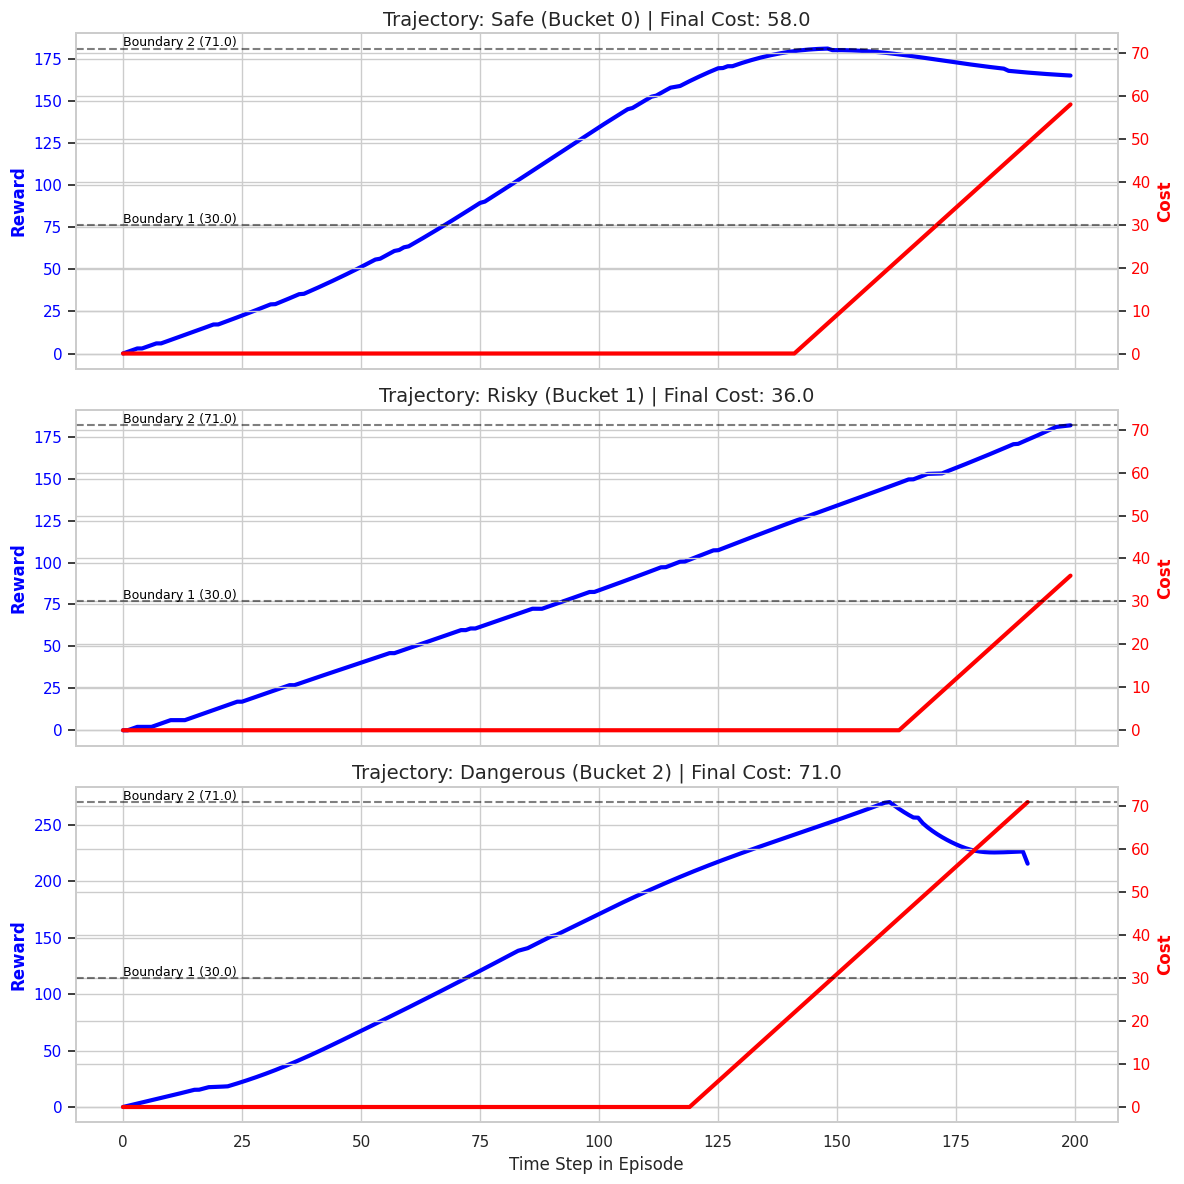

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure you've run the previous cell so 'env_episode_costs', 'dataset', etc. are loaded!
env_name = "OfflineCarCircle-v0" 
num_buckets = 3

# Extract the raw arrays from the dataset dictionary
costs = dataset.get('costs', dataset.get('cost'))
rewards = dataset.get('rewards', dataset.get('reward'))
terminals = dataset.get('terminals', dataset.get('dones'))
timeouts = dataset.get('timeouts', np.zeros_like(terminals, dtype=bool))

episode_ends = np.where(np.logical_or(terminals, timeouts))[0]

# 1. Calculate boundaries for this specific environment
ep_costs = env_episode_costs[env_name]
quantiles = np.linspace(0, 1, num_buckets + 1)[1:-1]
boundaries = np.quantile(ep_costs, quantiles)

# 2. Pick 3 specific episodes based on their final cost
safe_idx = np.argmin(np.abs(ep_costs - 0)) # Closest to 0 cost
risky_idx = np.argmin(np.abs(ep_costs - boundaries[0] * 1.5)) # Just past the first boundary
danger_idx = np.argmax(ep_costs) # The absolute worst crash

sample_episodes = [
    ("Safe (Bucket 0)", safe_idx),
    (f"Risky (Bucket 1)", risky_idx),
    (f"Dangerous (Bucket {num_buckets-1})", danger_idx)
]

# 3. Plotting
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
colors = sns.color_palette("Set1", 3)

for ax, (label, ep_idx) in zip(axes, sample_episodes):
    # Find the exact start and end steps for this episode in the raw data
    start_step = 0 if ep_idx == 0 else episode_ends[ep_idx - 1] + 1
    end_step = episode_ends[ep_idx]
    
    ep_raw_costs = costs[start_step:end_step + 1]
    ep_raw_rewards = rewards[start_step:end_step + 1]
    
    # Calculate the running totals step-by-step
    cumulative_costs = np.cumsum(ep_raw_costs)
    cumulative_rewards = np.cumsum(ep_raw_rewards)
    time_steps = np.arange(len(cumulative_costs))
    
    # Plot Reward (Primary Y-axis)
    ax.plot(time_steps, cumulative_rewards, label='Cumulative Reward', linewidth=3, color='blue')
    ax.set_ylabel("Reward", color='blue', fontweight='bold')
    ax.tick_params(axis='y', labelcolor='blue')
    
    # Plot Cost (Secondary Y-axis)
    ax2 = ax.twinx()
    ax2.plot(time_steps, cumulative_costs, label='Cumulative Cost', linewidth=3, color='red')
    ax2.set_ylabel("Cost", color='red', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='red')
    
    # Draw the Bucket Boundaries on the Cost axis
    for i, boundary in enumerate(boundaries):
        ax2.axhline(boundary, linestyle='--', color='black', alpha=0.5)
        ax2.text(0, boundary + 0.5, f"Boundary {i+1} ({boundary:.1f})", color='black', fontsize=9)
        
    ax.set_title(f"Trajectory: {label} | Final Cost: {cumulative_costs[-1]:.1f}", fontsize=14)
    
axes[-1].set_xlabel("Time Step in Episode", fontsize=12)
plt.tight_layout()
plt.show()

🔍 INSPECTING EPISODE 5 🔍
Total Steps: 200
----------------------------------------
Observations Shape: (200, 17)
Actions Shape:      (200, 4)
Total Reward:       244.14
Total Cost:         19.00
----------------------------------------
First 5 Steps Preview:
 Step  Obs_Dim_0 (e.g. X_pos)  Obs_Dim_1 (e.g. Y_pos)  Act_Dim_0 (e.g. Steer)  Reward  Cost
    0                   0.304                   0.090                  -0.302   0.000   0.0
    1                  -0.001                   0.001                   0.266   0.000   0.0
    2                  -0.001                   0.001                  -0.297   0.999   0.0
    3                  -0.001                   0.001                  -0.828   1.000   0.0
    4                  -0.001                   0.001                  -0.973  -0.003   0.0


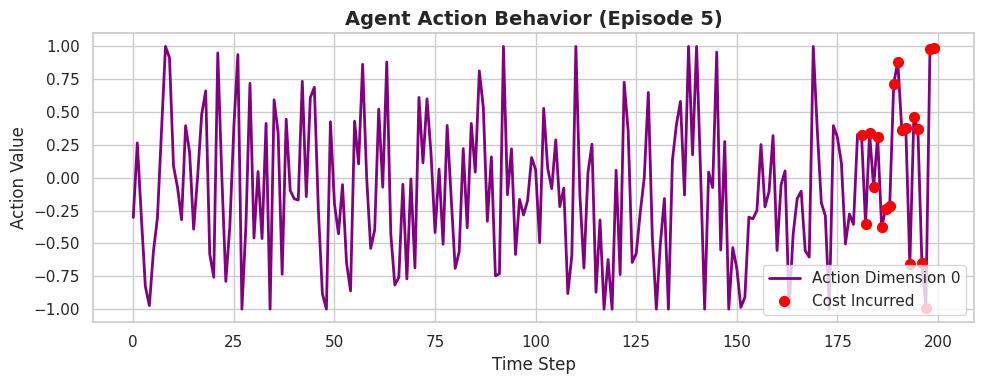

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# ==========================================
# 1. CHOOSE AN EPISODE TO INSPECT
# ==========================================
ep_idx = 5  # Change this number to look at different trajectories

# Calculate the exact slice indices for this episode
start_idx = 0 if ep_idx == 0 else episode_ends[ep_idx - 1] + 1
end_idx = episode_ends[ep_idx]
ep_length = end_idx - start_idx + 1

print(f"🔍 INSPECTING EPISODE {ep_idx} 🔍")
print(f"Total Steps: {ep_length}")
print("-" * 40)

# ==========================================
# 2. EXTRACT THE SLICES (Handling D4RL/DSRL naming variations)
# ==========================================
def get_slice(key_options):
    for k in key_options:
        if k in dataset:
            return dataset[k][start_idx:end_idx + 1]
    return None

obs = get_slice(['observations', 'states', 'obs'])
acts = get_slice(['actions', 'acts'])
rews = get_slice(['rewards', 'reward'])
costs = get_slice(['costs', 'cost'])

# ==========================================
# 3. PRINT SHAPES AND STATISTICS
# ==========================================
print(f"Observations Shape: {obs.shape}")
print(f"Actions Shape:      {acts.shape}")
print(f"Total Reward:       {np.sum(rews):.2f}")
print(f"Total Cost:         {np.sum(costs):.2f}")
print("-" * 40)

# Let's preview the first 5 steps in a clean Pandas DataFrame
# We'll just look at the first few dimensions of the observation space to keep it readable
preview_df = pd.DataFrame({
    "Step": range(5),
    "Obs_Dim_0 (e.g. X_pos)": obs[:5, 0].round(3),
    "Obs_Dim_1 (e.g. Y_pos)": obs[:5, 1].round(3),
    "Act_Dim_0 (e.g. Steer)": acts[:5, 0].round(3),
    "Reward": rews[:5].round(3),
    "Cost": costs[:5].round(3),
})
print("First 5 Steps Preview:")
print(preview_df.to_string(index=False))

# ==========================================
# 4. VISUALIZE SENSOR OR ACTION DATA
# ==========================================
# Let's plot how the first action dimension (e.g., steering/throttle) changes over time
plt.figure(figsize=(10, 4))
plt.plot(acts[:, 0], label="Action Dimension 0", color="purple", linewidth=2)

# If the episode had costs, let's highlight where they happened
cost_indices = np.where(costs > 0)[0]
if len(cost_indices) > 0:
    plt.scatter(cost_indices, acts[cost_indices, 0], color='red', s=50, 
                zorder=5, label="Cost Incurred")

plt.title(f"Agent Action Behavior (Episode {ep_idx})", fontsize=14, fontweight="bold")
plt.xlabel("Time Step")
plt.ylabel("Action Value")
plt.legend()
plt.tight_layout()
plt.show()